In [52]:
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold
#iterative-stratification is a project that provides scikit-learn compatible cross validators 
#with stratification for multilabel data.
#https://github.com/trent-b/iterative-stratification

In [53]:
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
import os
import copy
import seaborn as sns

from sklearn import preprocessing
from sklearn.metrics import log_loss
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import warnings
warnings.filterwarnings('ignore')
#https://pytorch.org/get-started/locally/#mac-anaconda
#https://github.com/pytorch/pytorch

In [54]:
from sklearn.preprocessing import QuantileTransformer

In [109]:
import torch 
print(torch.__version__)

1.5.1


In [86]:
train_features = pd.read_csv('train_features.csv') # /kaggle/input/lish-moa/
train_targets_scored = pd.read_csv('train_targets_scored.csv')
train_targets_nonscored = pd.read_csv('train_targets_nonscored.csv')

test_features = pd.read_csv('test_features.csv')
sample_submission = pd.read_csv('sample_submission.csv')

In [87]:
GENES = [col for col in train_features.columns if col.startswith('g-')]
CELLS = [col for col in train_features.columns if col.startswith('c-')]

In [88]:
# They are spiky distribution rather than normal distribution.
# Regardless of the train and test, they look be in the same shape.

In [89]:
#train set before using RankGauss

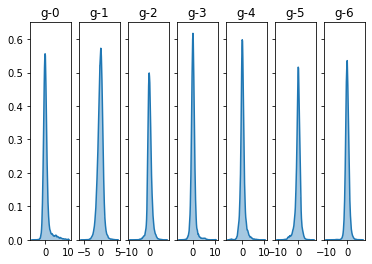

In [90]:
gnum = train_features[GENES].shape[1]
graphs = []

for i in range(0, gnum -1 , 7):
    #for least display.... 
    if i >= 3:
        break
    idxs = list(np.array([0, 1, 2, 3, 4, 5, 6]) + i)
    

    fig, axs = plt.subplots(1, 7, sharey=True)
    for k, item in enumerate(idxs):
        if item >=771:
            break
        graph = sns.distplot(train_features[GENES].values[:,item], ax=axs[k])
        graph.set_title(f"g-{item}")
        graphs.append(graph)

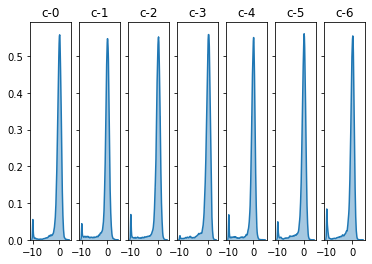

In [91]:
cnum = train_features[CELLS].shape[1]
graphs = []

for i in range(0, cnum -1 , 7):
    #for least display.... 
    if i >= 3:
        break
    idxs = list(np.array([0, 1, 2, 3, 4, 5, 6]) + i)
    

    fig, axs = plt.subplots(1, 7, sharey=True)
    for k, item in enumerate(idxs):
        if item >=100:
            break
        graph = sns.distplot(train_features[CELLS].values[:,item], ax=axs[k])
        graph.set_title(f"c-{item}")
        graphs.append(graph)

In [ ]:
#since the shape of the distribution is close to normal distribution to begin with, 
#we can forced  it to be transformed into a Gaussian distribution.

In [92]:
#RankGauss
#This method transforms the features to follow a uniform or a normal distribution.
#Therefore, for a given feature, this transformation tends to spread out the most frequent values.
#It also reduces the impact of (marginal) outliers: this is therefore a robust preprocessing scheme.
for col in (GENES + CELLS):

    transformer = QuantileTransformer(n_quantiles=100,random_state=0, output_distribution="normal")
    vec_len = len(train_features[col].values)
    vec_len_test = len(test_features[col].values)
    raw_vec = train_features[col].values.reshape(vec_len, 1)
    transformer.fit(raw_vec)

    train_features[col] = transformer.transform(raw_vec).reshape(1, vec_len)[0]
    test_features[col] = transformer.transform(test_features[col].values.reshape(vec_len_test, 1)).reshape(1, vec_len_test)[0]

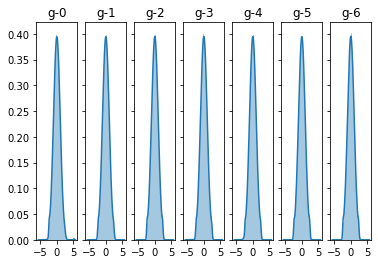

In [93]:
gnum = train_features[GENES].shape[1]
graphs = []

for i in range(0, gnum -1 , 7):
    #for least display.... 
    if i >= 3:
        break
    idxs = list(np.array([0, 1, 2, 3, 4, 5, 6]) + i)
    

    fig, axs = plt.subplots(1, 7, sharey=True)
    for k, item in enumerate(idxs):
        if item >=771:
            break
        graph = sns.distplot(train_features[GENES].values[:,item], ax=axs[k])
        graph.set_title(f"g-{item}")
        graphs.append(graph)

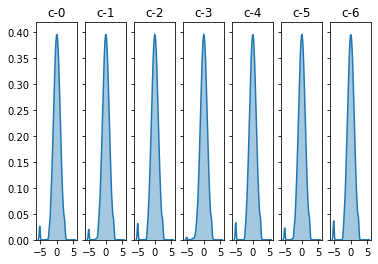

In [94]:
cnum = train_features[CELLS].shape[1]
graphs = []

for i in range(0, cnum -1 , 7):
    #for least display.... 
    if i >= 3:
        break
    idxs = list(np.array([0, 1, 2, 3, 4, 5, 6]) + i)
    

    fig, axs = plt.subplots(1, 7, sharey=True)
    for k, item in enumerate(idxs):
        if item >=100:
            break
        graph = sns.distplot(train_features[CELLS].values[:,item], ax=axs[k])
        graph.set_title(f"c-{item}")
        graphs.append(graph)

In [95]:
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    
seed_everything(seed=42)

In [96]:
#PCA features + Existing features¶

In [97]:
data = pd.concat([pd.DataFrame(train_features[GENES]), pd.DataFrame(test_features[GENES])])

In [98]:
data.shape

(27796, 772)

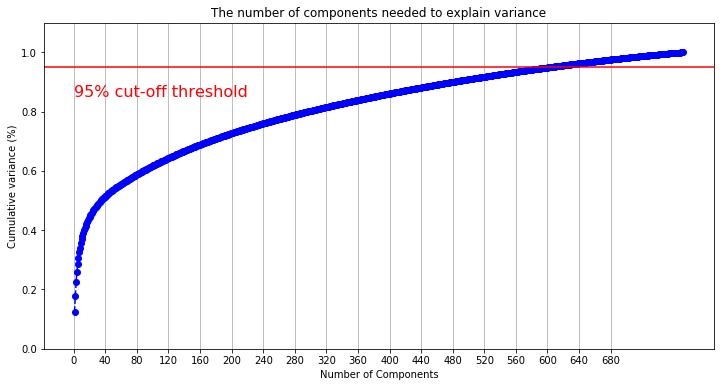

In [99]:
pca = PCA().fit(data)

import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (12,6)

fig, ax = plt.subplots()
xi = np.arange(1, 773, step=1)
y = np.cumsum(pca.explained_variance_ratio_)

plt.ylim(0.0,1.1)
plt.plot(xi, y, marker='o', linestyle='--', color='b')

plt.xlabel('Number of Components')
plt.xticks(np.arange(0, 720, step=40)) #change from 0-based array index to 1-based human-readable label
plt.ylabel('Cumulative variance (%)')
plt.title('The number of components needed to explain variance')

plt.axhline(y=0.95, color='r', linestyle='-')
plt.text(0.5, 0.85, '95% cut-off threshold', color = 'red', fontsize=16)

ax.grid(axis='x')
plt.show()

In [100]:
pca_df=pd.DataFrame(xi, columns=['Num_of_comp'])
pca_df['var']=y

In [103]:
pca_df[pca_df['var']>=0.95].head() # between 0.9-0.98

,Num_of_comp,var
603,604,0.950109
604,605,0.950467
605,606,0.950825
606,607,0.951183
607,608,0.951539


In [59]:
# GENES
n_comp = xx  #set by yourself

data = pd.concat([pd.DataFrame(train_features[GENES]), pd.DataFrame(test_features[GENES])])
data2 = (PCA(n_components=n_comp, random_state=42).fit_transform(data[GENES]))
train2 = data2[:train_features.shape[0]]; test2 = data2[-test_features.shape[0]:]

train2 = pd.DataFrame(train2, columns=[f'pca_G-{i}' for i in range(n_comp)])
test2 = pd.DataFrame(test2, columns=[f'pca_G-{i}' for i in range(n_comp)])

# drop_cols = [f'c-{i}' for i in range(n_comp,len(GENES))]
train_features = pd.concat((train_features, train2), axis=1)
test_features = pd.concat((test_features, test2), axis=1)

In [104]:
data = pd.concat([pd.DataFrame(train_features[CELLS]), pd.DataFrame(test_features[CELLS])])

In [105]:
data.shape

(27796, 100)

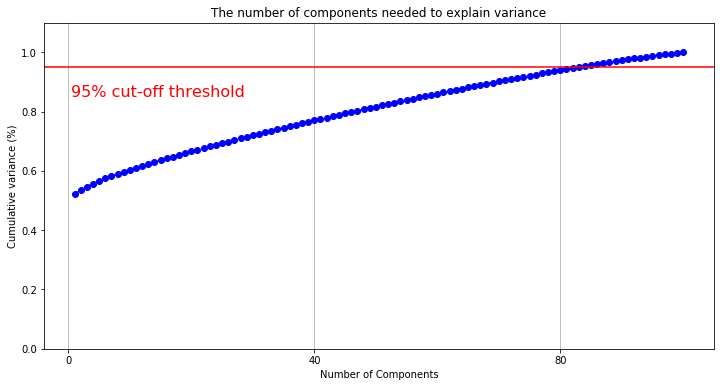

In [106]:
pca = PCA().fit(data)

import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (12,6)

fig, ax = plt.subplots()
xi = np.arange(1,101, step=1)
y = np.cumsum(pca.explained_variance_ratio_)

plt.ylim(0.0,1.1)
plt.plot(xi, y, marker='o', linestyle='--', color='b')

plt.xlabel('Number of Components')
plt.xticks(np.arange(0, 100, step=40)) #change from 0-based array index to 1-based human-readable label
plt.ylabel('Cumulative variance (%)')
plt.title('The number of components needed to explain variance')

plt.axhline(y=0.95, color='r', linestyle='-')
plt.text(0.5, 0.85, '95% cut-off threshold', color = 'red', fontsize=16)

ax.grid(axis='x')
plt.show()

In [107]:
pca_df=pd.DataFrame(xi, columns=['Num_of_comp'])
pca_df['var']=y

In [108]:
pca_df[pca_df['var']>=0.95].head()  # between 0.9-0.98

,Num_of_comp,var
82,83,0.950035
83,84,0.953499
84,85,0.956952
85,86,0.960322
86,87,0.963639


In [60]:
#CELLS
n_comp =xx   #set by yourself

data = pd.concat([pd.DataFrame(train_features[CELLS]), pd.DataFrame(test_features[CELLS])])
data2 = (PCA(n_components=n_comp, random_state=42).fit_transform(data[CELLS]))
train2 = data2[:train_features.shape[0]]; test2 = data2[-test_features.shape[0]:]

train2 = pd.DataFrame(train2, columns=[f'pca_C-{i}' for i in range(n_comp)])
test2 = pd.DataFrame(test2, columns=[f'pca_C-{i}' for i in range(n_comp)])

# drop_cols = [f'c-{i}' for i in range(n_comp,len(CELLS))]
train_features = pd.concat((train_features, train2), axis=1)
test_features = pd.concat((test_features, test2), axis=1)

In [61]:
train_features.shape

(23814, 1526)

In [ ]:
#feature Selection using Variance Encoding

In [62]:
from sklearn.feature_selection import VarianceThreshold

#Feature selector that removes all low-variance features.
var_thresh = VarianceThreshold(xx)   #set by yourself: 0.8-0.9
data = train_features.append(test_features)
data_transformed = var_thresh.fit_transform(data.iloc[:, 4:])

train_features_transformed = data_transformed[ : train_features.shape[0]]
test_features_transformed = data_transformed[-test_features.shape[0] : ]


train_features = pd.DataFrame(train_features[['sig_id','cp_type','cp_time','cp_dose']].values.reshape(-1, 4),\
                              columns=['sig_id','cp_type','cp_time','cp_dose'])

train_features = pd.concat([train_features, pd.DataFrame(train_features_transformed)], axis=1)


test_features = pd.DataFrame(test_features[['sig_id','cp_type','cp_time','cp_dose']].values.reshape(-1, 4),\
                             columns=['sig_id','cp_type','cp_time','cp_dose'])

test_features = pd.concat([test_features, pd.DataFrame(test_features_transformed)], axis=1)

train_features.shape

(23814, 1040)

In [ ]:
# create cluster

In [63]:
from sklearn.cluster import KMeans
def fe_cluster(train, test, n_clusters_g = 35, n_clusters_c = 5, SEED = 123): # try different values
    
    features_g = list(train.columns[4:776])
    features_c = list(train.columns[776:876])
    
    def create_cluster(train, test, features, kind = 'g', n_clusters = n_clusters_g):
        train_ = train[features].copy()
        test_ = test[features].copy()
        data = pd.concat([train_, test_], axis = 0)
        kmeans = KMeans(n_clusters = n_clusters, random_state = SEED).fit(data)
        train[f'clusters_{kind}'] = kmeans.labels_[:train.shape[0]]
        test[f'clusters_{kind}'] = kmeans.labels_[train.shape[0]:]
        train = pd.get_dummies(train, columns = [f'clusters_{kind}'])
        test = pd.get_dummies(test, columns = [f'clusters_{kind}'])
        return train, test
    
    train, test = create_cluster(train, test, features_g, kind = 'g', n_clusters = n_clusters_g)
    train, test = create_cluster(train, test, features_c, kind = 'c', n_clusters = n_clusters_c)
    return train, test

train_features ,test_features=fe_cluster(train_features,test_features)

In [ ]:
# create statistical analysis

In [64]:
def fe_stats(train, test):
    
    features_g = list(train.columns[4:776])
    features_c = list(train.columns[776:876])
    
    for df in train, test:
        df['g_sum'] = df[features_g].sum(axis = 1)
        df['g_mean'] = df[features_g].mean(axis = 1)
        df['g_std'] = df[features_g].std(axis = 1)
        df['g_kurt'] = df[features_g].kurtosis(axis = 1) # whether it is normal distribution
        df['g_skew'] = df[features_g].skew(axis = 1) # whether it is normal distribution
        df['c_sum'] = df[features_c].sum(axis = 1)
        df['c_mean'] = df[features_c].mean(axis = 1)
        df['c_std'] = df[features_c].std(axis = 1)
        df['c_kurt'] = df[features_c].kurtosis(axis = 1)
        df['c_skew'] = df[features_c].skew(axis = 1)
        df['gc_sum'] = df[features_g + features_c].sum(axis = 1)
        df['gc_mean'] = df[features_g + features_c].mean(axis = 1)
        df['gc_std'] = df[features_g + features_c].std(axis = 1)
        df['gc_kurt'] = df[features_g + features_c].kurtosis(axis = 1)
        df['gc_skew'] = df[features_g + features_c].skew(axis = 1)
        
    return train, test

train_features,test_features=fe_stats(train_features,test_features)

In [65]:
train = train_features.merge(train_targets_scored, on='sig_id')
train = train[train['cp_type']!='ctl_vehicle'].reset_index(drop=True)
test = test_features[test_features['cp_type']!='ctl_vehicle'].reset_index(drop=True)

target = train[train_targets_scored.columns]

In [66]:
train = train.drop('cp_type', axis=1)
test = test.drop('cp_type', axis=1)

In [67]:
train.shape

(21948, 1300)

In [68]:
train.head()

,sig_id,cp_time,cp_dose,0,1,2,3,4,5,6,...,tropomyosin_receptor_kinase_inhibitor,trpv_agonist,trpv_antagonist,tubulin_inhibitor,tyrosine_kinase_inhibitor,ubiquitin_specific_protease_inhibitor,vegfr_inhibitor,vitamin_b,vitamin_d_receptor_agonist,wnt_inhibitor
0,id_000644bb2,24,D1,1.134849,0.907687,-0.416385,-0.966814,-0.254723,-1.017473,-1.364787,...,0,0,0,0,0,0,0,0,0,0
1,id_000779bfc,72,D1,0.119282,0.681738,0.272399,0.080113,1.205169,0.686517,0.313396,...,0,0,0,0,0,0,0,0,0,0
2,id_000a6266a,48,D1,0.779973,0.946463,1.425350,-0.132928,-0.006122,1.492493,0.235577,...,0,0,0,0,0,0,0,0,0,0
3,id_0015fd391,48,D1,-0.734910,-0.274641,-0.438509,0.759097,2.346330,-0.858153,-2.288417,...,0,0,0,0,0,0,0,0,0,0
4,id_001626bd3,72,D2,-0.452718,-0.477513,0.972316,0.970731,1.463427,-0.869555,-0.375501,...,0,0,0,0,0,0,0,0,0,0


In [69]:
target_cols = target.drop('sig_id', axis=1).columns.values.tolist()

In [70]:
len(target_cols)

206

In [71]:
folds = train.copy()

mskf = MultilabelStratifiedKFold(n_splits=xx) # set by yourself: 5-10

for f, (t_idx, v_idx) in enumerate(mskf.split(X=train, y=target)):
    folds.loc[v_idx, 'kfold'] = int(f)

folds['kfold'] = folds['kfold'].astype(int)
folds

,sig_id,cp_time,cp_dose,0,1,2,3,4,5,6,...,trpv_agonist,trpv_antagonist,tubulin_inhibitor,tyrosine_kinase_inhibitor,ubiquitin_specific_protease_inhibitor,vegfr_inhibitor,vitamin_b,vitamin_d_receptor_agonist,wnt_inhibitor,kfold
0,id_000644bb2,24,D1,1.134849,0.907687,-0.416385,-0.966814,-0.254723,-1.017473,-1.364787,...,0,0,0,0,0,0,0,0,0,5
1,id_000779bfc,72,D1,0.119282,0.681738,0.272399,0.080113,1.205169,0.686517,0.313396,...,0,0,0,0,0,0,0,0,0,0
2,id_000a6266a,48,D1,0.779973,0.946463,1.425350,-0.132928,-0.006122,1.492493,0.235577,...,0,0,0,0,0,0,0,0,0,6
3,id_0015fd391,48,D1,-0.734910,-0.274641,-0.438509,0.759097,2.346330,-0.858153,-2.288417,...,0,0,0,0,0,0,0,0,0,0
4,id_001626bd3,72,D2,-0.452718,-0.477513,0.972316,0.970731,1.463427,-0.869555,-0.375501,...,0,0,0,0,0,0,0,0,0,4
5,id_001762a82,24,D1,-0.880697,0.508160,-1.416109,0.335123,1.391083,0.686071,0.080179,...,0,0,0,0,0,0,0,0,0,2
6,id_001bd861f,24,D2,1.500212,2.153865,-1.834969,2.477495,-2.291874,-2.206654,2.427419,...,0,0,0,0,0,0,0,0,0,6
7,id_0020d0484,48,D1,0.372970,0.841985,-0.264910,2.061578,0.926238,0.763292,-0.354035,...,0,0,0,0,0,0,0,0,0,2
8,id_00224bf20,48,D1,-0.417590,0.902769,-0.428691,-0.231764,-0.921987,-0.678041,-1.021121,...,0,0,0,0,0,0,0,0,0,0
9,id_0023f063e,48,D2,-0.077234,0.453862,-0.799807,-0.412610,0.012988,-1.339064,-0.295002,...,0,0,0,0,0,0,0,0,0,5


In [72]:
print(train.shape)
print(folds.shape)
print(test.shape)
print(target.shape)
print(sample_submission.shape)

(21948, 1300)
(21948, 1301)
(3624, 1094)
(21948, 207)
(3982, 207)


In [73]:
class MoADataset:
    def __init__(self, features, targets):
        self.features = features
        self.targets = targets
        
    def __len__(self):
        return (self.features.shape[0])
    
    def __getitem__(self, idx):
        dct = {
            'x' : torch.tensor(self.features[idx, :], dtype=torch.float),
            'y' : torch.tensor(self.targets[idx, :], dtype=torch.float)            
        }
        return dct
    
class TestDataset:
    def __init__(self, features):
        self.features = features
        
    def __len__(self):
        return (self.features.shape[0])
    
    def __getitem__(self, idx):
        dct = {
            'x' : torch.tensor(self.features[idx, :], dtype=torch.float)
        }
        return dct

In [74]:
def train_fn(model, optimizer, scheduler, loss_fn, dataloader, device): # training
    model.train()
    final_loss = 0
    
    for data in dataloader:
        optimizer.zero_grad() 
        inputs, targets = data['x'].to(device), data['y'].to(device)
#         print(inputs.shape)
        outputs = model(inputs)# feed forward
        loss = loss_fn(outputs, targets)
        loss.backward()# backpropgation 
        optimizer.step()
        scheduler.step()
        
        final_loss += loss.item()
        
    final_loss /= len(dataloader)
    
    return final_loss


def valid_fn(model, loss_fn, dataloader, device): # validation prediction
    model.eval()
    final_loss = 0
    valid_preds = []
    
    for data in dataloader:
        inputs, targets = data['x'].to(device), data['y'].to(device)
        outputs = model(inputs)
        loss = loss_fn(outputs, targets)
        
        final_loss += loss.item()
        valid_preds.append(outputs.sigmoid().detach().cpu().numpy())
        
    final_loss /= len(dataloader)
    valid_preds = np.concatenate(valid_preds)
    
    return final_loss, valid_preds

def inference_fn(model, dataloader, device): # test prediction
    model.eval()
    preds = []
    
    for data in dataloader:
        inputs = data['x'].to(device)

        with torch.no_grad():
            outputs = model(inputs)
        
        preds.append(outputs.sigmoid().detach().cpu().numpy())
        
    preds = np.concatenate(preds)
    
    return preds

In [75]:
import torch
from torch.nn.modules.loss import _WeightedLoss
import torch.nn.functional as F

#smoothing:https://www.kaggle.com/kailex/moa-transfer-recipe-with-smoothing
class SmoothBCEwLogits(_WeightedLoss):
    def __init__(self, weight=None, reduction='mean', smoothing=0.0):
        super().__init__(weight=weight, reduction=reduction)
        self.smoothing = smoothing
        self.weight = weight
        self.reduction = reduction

    @staticmethod
    def _smooth(targets:torch.Tensor, n_labels:int, smoothing=0.0):
        assert 0 <= smoothing < 1
        with torch.no_grad():
            targets = targets * (1.0 - smoothing) + 0.5 * smoothing
        return targets

    def forward(self, inputs, targets):
        targets = SmoothBCEwLogits._smooth(targets, inputs.size(-1),
            self.smoothing)
        loss = F.binary_cross_entropy_with_logits(inputs, targets,self.weight)

        if  self.reduction == 'sum':
            loss = loss.sum()
        elif  self.reduction == 'mean':
            loss = loss.mean()

        return loss

In [76]:
class Model(nn.Module):      # <-- Update
    def __init__(self, num_features, num_targets, hidden_size):
        super(Model, self).__init__()
        self.batch_norm1 = nn.BatchNorm1d(num_features)
        # Batch Normalization: Accelerating Deep Network Training by Reducing Internal Covariate Shift
        #https://pytorch.org/docs/stable/generated/torch.nn.BatchNorm1d.html
        self.dense1 = nn.utils.weight_norm(nn.Linear(num_features, hidden_size))
        #Weight normalization is a reparameterization that decouples the magnitude of a weight tensor from its direction. 
        #https://pytorch.org/docs/stable/generated/torch.nn.utils.weight_norm.html
        
        self.batch_norm2 = nn.BatchNorm1d(hidden_size)
        self.dropout2 = nn.Dropout(0.4)
        #During training, randomly zeroes some of the elements of the input tensor 
        #with probability p using samples from a Bernoulli distribution. 
        #Each channel will be zeroed out independently on every forward call.
        #This has proven to be an effective technique for regularization and preventing the co-adaptation of neurons
        #https://pytorch.org/docs/stable/generated/torch.nn.Dropout.html
        self.dense2 = nn.utils.weight_norm(nn.Linear(hidden_size, hidden_size))
        
        self.batch_norm3 = nn.BatchNorm1d(hidden_size)
        self.dropout3 = nn.Dropout(0.4)
        self.dense3 = nn.utils.weight_norm(nn.Linear(hidden_size, num_targets))
    
    def forward(self, x):
        x = self.batch_norm1(x)
        x = F.relu(self.dense1(x))
        
        x = self.batch_norm2(x)
        x = self.dropout2(x)
        x = F.relu(self.dense2(x))
        
        x = self.batch_norm3(x)
        x = self.dropout3(x)
        x = self.dense3(x)
        
        return x

In [ ]:
# categorical to dummy

In [77]:
def process_data(data):
    data = pd.get_dummies(data, columns=['cp_time','cp_dose'])
    return data

In [78]:
feature_cols = [c for c in process_data(folds).columns if c not in target_cols]
feature_cols = [c for c in feature_cols if c not in ['kfold','sig_id']]
len(feature_cols)

1096

In [79]:
# HyperParameters

DEVICE = ('cuda' if torch.cuda.is_available() else 'cpu')
EPOCHS = xx
# set by yourself: 25-45
#In terms of artificial neural networks, an epoch refers to one cycle through the full training dataset. 
# Usually, training a neural network takes more than a few epochs. In other words,
# if we feed a neural network the training data for more than one epoch in different patterns, 
# we hope for a better generalization when given a new "unseen" input (test data). 
# An epoch is often mixed up with an iteration. Iterations is the number of batches
# or steps through partitioned packets of the training data, needed to complete one epoch.
BATCH_SIZE =  xx
# set by yourself: 100-200
# The batch size defines the number of samples that will be propagated through the network.

# For instance, let's say you have 1050 training samples and you want to set up a batch_size equal to 100. 
# The algorithm takes the first 100 samples (from 1st to 100th) from the training dataset and trains the network.
# Next, it takes the second 100 samples (from 101st to 200th) and trains the network again. 
# We can keep doing this procedure until we have propagated all samples through of the network.
# Problem might happen with the last set of samples. 
# In our example, we've used 1050 which is not divisible by 100 without remainder. 
# The simplest solution is just to get the final 50 samples and train the network.

# Advantages of using a batch size < number of all samples:

# It requires less memory. Since you train the network using fewer samples, 
# the overall training procedure requires less memory.
# That's especially important if you are not able to fit the whole dataset in your machine's memory.

# Typically networks train faster with mini-batches. 
# That's because we update the weights after each propagation. 
# In our example we've propagated 11 batches (10 of them had 100 samples and 1 had 50 samples) 
# and after each of them we've updated our network's parameters. 
# If we used all samples during propagation we would make only 1 update for the network's parameter.

# Disadvantages of using a batch size < number of all samples:

# The smaller the batch the less accurate the estimate of the gradient will be
LEARNING_RATE = 1e-3
# It controls how quickly or slowly a neural network model learns a problem.
WEIGHT_DECAY = 1e-5
# Is a regularisation technique used to avoid over-fitting.
# The learning rate is a parameter that determines how much an updating step influences the current value 
# of the weights. While weight decay is an additional term in the weight update rule that causes the weights
# to exponentially decay to zero, if no other update is scheduled.
#https://stats.stackexchange.com/questions/29130/difference-between-neural-net-weight-decay-and-learning-rate
NFOLDS = xx          #same as before
EARLY_STOPPING_STEPS = 10
EARLY_STOP = False

num_features=len(feature_cols)
num_targets=len(target_cols)
hidden_size=2048

In [80]:
def run_training(fold, seed):
    
    seed_everything(seed)
    
    train = process_data(folds)
    test_ = process_data(test)
    
    trn_idx = train[train['kfold'] != fold].index
    val_idx = train[train['kfold'] == fold].index
    
    train_df = train[train['kfold'] != fold].reset_index(drop=True)
    valid_df = train[train['kfold'] == fold].reset_index(drop=True)
    
    x_train, y_train  = train_df[feature_cols].values, train_df[target_cols].values
    x_valid, y_valid =  valid_df[feature_cols].values, valid_df[target_cols].values
    
    train_dataset = MoADataset(x_train, y_train)
    valid_dataset = MoADataset(x_valid, y_valid)
    trainloader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    validloader = torch.utils.data.DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)
    
    model = Model(
        num_features=num_features,
        num_targets=num_targets,
        hidden_size=hidden_size,
    )
    
    model.to(DEVICE)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.OneCycleLR(optimizer=optimizer, pct_start=0.1, div_factor=1e3, 
                                              max_lr=1e-2, epochs=EPOCHS, steps_per_epoch=len(trainloader))
    
    loss_fn = nn.BCEWithLogitsLoss()
    
    loss_tr = SmoothBCEwLogits(smoothing =0.001)
    
    early_stopping_steps = EARLY_STOPPING_STEPS
    early_step = 0
    
    oof = np.zeros((len(train), target.iloc[:, 1:].shape[1]))
    best_loss = np.inf
    
    for epoch in range(EPOCHS):
        
        train_loss = train_fn(model, optimizer,scheduler, loss_tr, trainloader, DEVICE)
        print(f"SEED: {seed}, FOLD: {fold}, EPOCH: {epoch}, train_loss: {train_loss}")
        valid_loss, valid_preds = valid_fn(model, loss_fn, validloader, DEVICE)
        print(f"SEED: {seed} ,FOLD: {fold}, EPOCH: {epoch}, valid_loss: {valid_loss}")
        
        if valid_loss < best_loss:
            
            best_loss = valid_loss
            oof[val_idx] = valid_preds
            torch.save(model.state_dict(), f"FOLD{fold}_.pth")
        
        elif(EARLY_STOP == True):
            
            early_step += 1
            if (early_step >= early_stopping_steps):
                break
            
    
    #--------------------- PREDICTION---------------------
    x_test = test_[feature_cols].values
    testdataset = TestDataset(x_test)
    testloader = torch.utils.data.DataLoader(testdataset, batch_size=BATCH_SIZE, shuffle=False)
    
    model = Model(
        num_features=num_features,
        num_targets=num_targets,
        hidden_size=hidden_size,

    )
    
    model.load_state_dict(torch.load(f"FOLD{fold}_.pth"))
    model.to(DEVICE)
    
    predictions = np.zeros((len(test_), target.iloc[:, 1:].shape[1]))
    predictions = inference_fn(model, testloader, DEVICE)
    
    return oof, predictions

In [81]:
def run_k_fold(NFOLDS, seed):
    oof = np.zeros((len(train), len(target_cols)))
    predictions = np.zeros((len(test), len(target_cols)))
    
    for fold in range(NFOLDS):
        oof_, pred_ = run_training(fold, seed)
        
        predictions += pred_ / NFOLDS
        oof += oof_
        
    return oof, predictions

In [82]:
# Averaging on multiple SEEDS

SEED = [x,x,x,x,x,x...]  #set by yourself: 3-7
oof = np.zeros((len(train), len(target_cols)))
predictions = np.zeros((len(test), len(target_cols)))

for seed in SEED:
    
    oof_, predictions_ = run_k_fold(NFOLDS, seed)
    oof += oof_ / len(SEED)
    predictions += predictions_ / len(SEED)

train[target_cols] = oof

SEED: 0, FOLD: 0, EPOCH: 0, train_loss: 0.4790948737843507
SEED: 0 ,FOLD: 0, EPOCH: 0, valid_loss: 0.023851210474967955
SEED: 0, FOLD: 0, EPOCH: 1, train_loss: 0.024288884040956596
SEED: 0 ,FOLD: 0, EPOCH: 1, valid_loss: 0.019547936022281647
SEED: 0, FOLD: 0, EPOCH: 2, train_loss: 0.0223551634192264
SEED: 0 ,FOLD: 0, EPOCH: 2, valid_loss: 0.018021041452884676
SEED: 0, FOLD: 0, EPOCH: 3, train_loss: 0.021006814704663087
SEED: 0 ,FOLD: 0, EPOCH: 3, valid_loss: 0.01761142697185278
SEED: 0, FOLD: 0, EPOCH: 4, train_loss: 0.020384943176086256
SEED: 0 ,FOLD: 0, EPOCH: 4, valid_loss: 0.017374838590621947
SEED: 0, FOLD: 0, EPOCH: 5, train_loss: 0.02020121040139474
SEED: 0 ,FOLD: 0, EPOCH: 5, valid_loss: 0.01722944300621748
SEED: 0, FOLD: 0, EPOCH: 6, train_loss: 0.02028072344101205
SEED: 0 ,FOLD: 0, EPOCH: 6, valid_loss: 0.017377763763070108
SEED: 0, FOLD: 0, EPOCH: 7, train_loss: 0.02030122560151175
SEED: 0 ,FOLD: 0, EPOCH: 7, valid_loss: 0.01727131560444832
SEED: 0, FOLD: 0, EPOCH: 8, train_

SEED: 0 ,FOLD: 2, EPOCH: 17, valid_loss: 0.016590614318847657
SEED: 0, FOLD: 2, EPOCH: 18, train_loss: 0.01928125354809826
SEED: 0 ,FOLD: 2, EPOCH: 18, valid_loss: 0.016445948742330074
SEED: 0, FOLD: 2, EPOCH: 19, train_loss: 0.01897754920583193
SEED: 0 ,FOLD: 2, EPOCH: 19, valid_loss: 0.01632431473582983
SEED: 0, FOLD: 2, EPOCH: 20, train_loss: 0.018638655416616776
SEED: 0 ,FOLD: 2, EPOCH: 20, valid_loss: 0.016218233443796633
SEED: 0, FOLD: 2, EPOCH: 21, train_loss: 0.01829030891867722
SEED: 0 ,FOLD: 2, EPOCH: 21, valid_loss: 0.016147012189030648
SEED: 0, FOLD: 2, EPOCH: 22, train_loss: 0.017897101771720006
SEED: 0 ,FOLD: 2, EPOCH: 22, valid_loss: 0.016055709719657897
SEED: 0, FOLD: 2, EPOCH: 23, train_loss: 0.017603387074152224
SEED: 0 ,FOLD: 2, EPOCH: 23, valid_loss: 0.016018133498728274
SEED: 0, FOLD: 2, EPOCH: 24, train_loss: 0.017456303249258977
SEED: 0 ,FOLD: 2, EPOCH: 24, valid_loss: 0.01600800283253193
SEED: 0, FOLD: 3, EPOCH: 0, train_loss: 0.4804005559888624
SEED: 0 ,FOLD: 3

SEED: 0, FOLD: 5, EPOCH: 10, train_loss: 0.020374279849383295
SEED: 0 ,FOLD: 5, EPOCH: 10, valid_loss: 0.01748654928058386
SEED: 0, FOLD: 5, EPOCH: 11, train_loss: 0.020285181270367433
SEED: 0 ,FOLD: 5, EPOCH: 11, valid_loss: 0.01754264026880264
SEED: 0, FOLD: 5, EPOCH: 12, train_loss: 0.020315937102347813
SEED: 0 ,FOLD: 5, EPOCH: 12, valid_loss: 0.01705947257578373
SEED: 0, FOLD: 5, EPOCH: 13, train_loss: 0.020177422712246578
SEED: 0 ,FOLD: 5, EPOCH: 13, valid_loss: 0.01723486162722111
SEED: 0, FOLD: 5, EPOCH: 14, train_loss: 0.020105892931725704
SEED: 0 ,FOLD: 5, EPOCH: 14, valid_loss: 0.01702506858855486
SEED: 0, FOLD: 5, EPOCH: 15, train_loss: 0.019915085336586244
SEED: 0 ,FOLD: 5, EPOCH: 15, valid_loss: 0.01691592775285244
SEED: 0, FOLD: 5, EPOCH: 16, train_loss: 0.01972053949499414
SEED: 0 ,FOLD: 5, EPOCH: 16, valid_loss: 0.017043663114309313
SEED: 0, FOLD: 5, EPOCH: 17, train_loss: 0.019601896760009584
SEED: 0 ,FOLD: 5, EPOCH: 17, valid_loss: 0.016837600581347943
SEED: 0, FOLD: 

SEED: 1, FOLD: 1, EPOCH: 2, train_loss: 0.022287886146278607
SEED: 1 ,FOLD: 1, EPOCH: 2, valid_loss: 0.018024071082472802
SEED: 1, FOLD: 1, EPOCH: 3, train_loss: 0.020966007583299463
SEED: 1 ,FOLD: 1, EPOCH: 3, valid_loss: 0.017404763884842397
SEED: 1, FOLD: 1, EPOCH: 4, train_loss: 0.020338249475169344
SEED: 1 ,FOLD: 1, EPOCH: 4, valid_loss: 0.017098370268940927
SEED: 1, FOLD: 1, EPOCH: 5, train_loss: 0.020227777106421336
SEED: 1 ,FOLD: 1, EPOCH: 5, valid_loss: 0.017113746404647828
SEED: 1, FOLD: 1, EPOCH: 6, train_loss: 0.020381985523668277
SEED: 1 ,FOLD: 1, EPOCH: 6, valid_loss: 0.017279404662549496
SEED: 1, FOLD: 1, EPOCH: 7, train_loss: 0.02039578507597349
SEED: 1 ,FOLD: 1, EPOCH: 7, valid_loss: 0.0171692219004035
SEED: 1, FOLD: 1, EPOCH: 8, train_loss: 0.020433410761409067
SEED: 1 ,FOLD: 1, EPOCH: 8, valid_loss: 0.017272361665964128
SEED: 1, FOLD: 1, EPOCH: 9, train_loss: 0.02046168727331421
SEED: 1 ,FOLD: 1, EPOCH: 9, valid_loss: 0.01712795875966549
SEED: 1, FOLD: 1, EPOCH: 10, 

SEED: 1, FOLD: 3, EPOCH: 19, train_loss: 0.019045207624127265
SEED: 1 ,FOLD: 3, EPOCH: 19, valid_loss: 0.016528233140707015
SEED: 1, FOLD: 3, EPOCH: 20, train_loss: 0.018709961933140853
SEED: 1 ,FOLD: 3, EPOCH: 20, valid_loss: 0.0163632483035326
SEED: 1, FOLD: 3, EPOCH: 21, train_loss: 0.01835282725997928
SEED: 1 ,FOLD: 3, EPOCH: 21, valid_loss: 0.016281942650675774
SEED: 1, FOLD: 3, EPOCH: 22, train_loss: 0.018016540971236165
SEED: 1 ,FOLD: 3, EPOCH: 22, valid_loss: 0.016224636994302273
SEED: 1, FOLD: 3, EPOCH: 23, train_loss: 0.017694274159971955
SEED: 1 ,FOLD: 3, EPOCH: 23, valid_loss: 0.01618899304419756
SEED: 1, FOLD: 3, EPOCH: 24, train_loss: 0.017596454619347644
SEED: 1 ,FOLD: 3, EPOCH: 24, valid_loss: 0.016184007413685322
SEED: 1, FOLD: 4, EPOCH: 0, train_loss: 0.48076166529335135
SEED: 1 ,FOLD: 4, EPOCH: 0, valid_loss: 0.02499705374240875
SEED: 1, FOLD: 4, EPOCH: 1, train_loss: 0.024241006470659153
SEED: 1 ,FOLD: 4, EPOCH: 1, valid_loss: 0.019476369991898536
SEED: 1, FOLD: 4, 

...

SEED: 5, FOLD: 5, EPOCH: 7, train_loss: 0.020332536020246494
SEED: 5 ,FOLD: 5, EPOCH: 7, valid_loss: 0.01747616283595562
SEED: 5, FOLD: 5, EPOCH: 8, train_loss: 0.020358880779066054
SEED: 5 ,FOLD: 5, EPOCH: 8, valid_loss: 0.017566220089793205
SEED: 5, FOLD: 5, EPOCH: 9, train_loss: 0.02041353992357546
SEED: 5 ,FOLD: 5, EPOCH: 9, valid_loss: 0.0177360075712204
SEED: 5, FOLD: 5, EPOCH: 10, train_loss: 0.02039438774999307
SEED: 5 ,FOLD: 5, EPOCH: 10, valid_loss: 0.017487640902400018
SEED: 5, FOLD: 5, EPOCH: 11, train_loss: 0.02034821760441576
SEED: 5 ,FOLD: 5, EPOCH: 11, valid_loss: 0.01732381943613291
SEED: 5, FOLD: 5, EPOCH: 12, train_loss: 0.020246360539680437
SEED: 5 ,FOLD: 5, EPOCH: 12, valid_loss: 0.01723849307745695
SEED: 5, FOLD: 5, EPOCH: 13, train_loss: 0.020201417421098468
SEED: 5 ,FOLD: 5, EPOCH: 13, valid_loss: 0.01717719592154026
SEED: 5, FOLD: 5, EPOCH: 14, train_loss: 0.02009063229268911
SEED: 5 ,FOLD: 5, EPOCH: 14, valid_loss: 0.017091114073991776
SEED: 5, FOLD: 5, EPOCH:

SEED: 6, FOLD: 0, EPOCH: 24, train_loss: 0.01752609871074456
SEED: 6 ,FOLD: 0, EPOCH: 24, valid_loss: 0.016123742423951627
SEED: 6, FOLD: 1, EPOCH: 0, train_loss: 0.4810465524087147
SEED: 6 ,FOLD: 1, EPOCH: 0, valid_loss: 0.024387855753302573
SEED: 6, FOLD: 1, EPOCH: 1, train_loss: 0.024437033818388472
SEED: 6 ,FOLD: 1, EPOCH: 1, valid_loss: 0.01919355593621731
SEED: 6, FOLD: 1, EPOCH: 2, train_loss: 0.022695313416877572
SEED: 6 ,FOLD: 1, EPOCH: 2, valid_loss: 0.017929785549640656
SEED: 6, FOLD: 1, EPOCH: 3, train_loss: 0.02110241482756576
SEED: 6 ,FOLD: 1, EPOCH: 3, valid_loss: 0.017450968585908413
SEED: 6, FOLD: 1, EPOCH: 4, train_loss: 0.020514902107569635
SEED: 6 ,FOLD: 1, EPOCH: 4, valid_loss: 0.017174717597663404
SEED: 6, FOLD: 1, EPOCH: 5, train_loss: 0.02026802526951647
SEED: 6 ,FOLD: 1, EPOCH: 5, valid_loss: 0.017022050693631174
SEED: 6, FOLD: 1, EPOCH: 6, train_loss: 0.02035707290455395
SEED: 6 ,FOLD: 1, EPOCH: 6, valid_loss: 0.01728063352406025
SEED: 6, FOLD: 1, EPOCH: 7, tr

SEED: 6 ,FOLD: 3, EPOCH: 16, valid_loss: 0.016925536915659904
SEED: 6, FOLD: 3, EPOCH: 17, train_loss: 0.01953553367836946
SEED: 6 ,FOLD: 3, EPOCH: 17, valid_loss: 0.016809429377317428
SEED: 6, FOLD: 3, EPOCH: 18, train_loss: 0.019315522506224866
SEED: 6 ,FOLD: 3, EPOCH: 18, valid_loss: 0.01665801141411066
SEED: 6, FOLD: 3, EPOCH: 19, train_loss: 0.019016905630729636
SEED: 6 ,FOLD: 3, EPOCH: 19, valid_loss: 0.016448400132358074
SEED: 6, FOLD: 3, EPOCH: 20, train_loss: 0.018676437817665995
SEED: 6 ,FOLD: 3, EPOCH: 20, valid_loss: 0.016331783570349215
SEED: 6, FOLD: 3, EPOCH: 21, train_loss: 0.018279673759730494
SEED: 6 ,FOLD: 3, EPOCH: 21, valid_loss: 0.016294983327388764
SEED: 6, FOLD: 3, EPOCH: 22, train_loss: 0.017909210168940273
SEED: 6 ,FOLD: 3, EPOCH: 22, valid_loss: 0.01621938295662403
SEED: 6, FOLD: 3, EPOCH: 23, train_loss: 0.01757169427464203
SEED: 6 ,FOLD: 3, EPOCH: 23, valid_loss: 0.01617990795522928
SEED: 6, FOLD: 3, EPOCH: 24, train_loss: 0.01746297683440098
SEED: 6 ,FOLD:

SEED: 6, FOLD: 6, EPOCH: 9, train_loss: 0.020341791795427295
SEED: 6 ,FOLD: 6, EPOCH: 9, valid_loss: 0.017149022929370403
SEED: 6, FOLD: 6, EPOCH: 10, train_loss: 0.02037500062970077
SEED: 6 ,FOLD: 6, EPOCH: 10, valid_loss: 0.017095658779144287
SEED: 6, FOLD: 6, EPOCH: 11, train_loss: 0.020343361346393217
SEED: 6 ,FOLD: 6, EPOCH: 11, valid_loss: 0.017275085560977458
SEED: 6, FOLD: 6, EPOCH: 12, train_loss: 0.020294865327222005
SEED: 6 ,FOLD: 6, EPOCH: 12, valid_loss: 0.017314285077154636
SEED: 6, FOLD: 6, EPOCH: 13, train_loss: 0.020192893931553477
SEED: 6 ,FOLD: 6, EPOCH: 13, valid_loss: 0.017026561833918093
SEED: 6, FOLD: 6, EPOCH: 14, train_loss: 0.02015890516847575
SEED: 6 ,FOLD: 6, EPOCH: 14, valid_loss: 0.016854449920356274
SEED: 6, FOLD: 6, EPOCH: 15, train_loss: 0.01998443729212495
SEED: 6 ,FOLD: 6, EPOCH: 15, valid_loss: 0.016805204711854458
SEED: 6, FOLD: 6, EPOCH: 16, train_loss: 0.01978168644163073
SEED: 6 ,FOLD: 6, EPOCH: 16, valid_loss: 0.016655668206512927
SEED: 6, FOLD:

KeyError: "None of [Index(['5-alpha_reductase_inhibitor', '11-beta-hsd1_inhibitor',\n       'acat_inhibitor', 'acetylcholine_receptor_agonist',\n       'acetylcholine_receptor_antagonist', 'acetylcholinesterase_inhibitor',\n       'adenosine_receptor_agonist', 'adenosine_receptor_antagonist',\n       'adenylyl_cyclase_activator', 'adrenergic_receptor_agonist',\n       ...\n       'tropomyosin_receptor_kinase_inhibitor', 'trpv_agonist',\n       'trpv_antagonist', 'tubulin_inhibitor', 'tyrosine_kinase_inhibitor',\n       'ubiquitin_specific_protease_inhibitor', 'vegfr_inhibitor', 'vitamin_b',\n       'vitamin_d_receptor_agonist', 'wnt_inhibitor'],\n      dtype='object', length=206)] are in the [columns]"

In [83]:
for i in range(len(target_cols)):
    fea=target_cols[i]
    test[fea]=predictions[:,i]

In [84]:
valid_results = train_targets_scored.drop(columns=target_cols).merge(train[['sig_id']+target_cols], on='sig_id', how='left').fillna(0)


y_true = train_targets_scored[target_cols].values
y_pred = valid_results[target_cols].values

score = 0
for i in range(len(target_cols)):
    score_ = log_loss(y_true[:, i], y_pred[:, i])
    score += score_ / target.shape[1]
    
print("CV log_loss: ", score) # minimize avg validation loss

CV log_loss:  0.014681458126955248


In [85]:
sub = sample_submission.drop(columns=target_cols).merge(test[['sig_id']+target_cols], on='sig_id', how='left').fillna(0)
sub.to_csv('sub_pytroch2.csv', index=False)

In [ ]:
# task of this week
# merge team
# tune your parameter to find the best model that has the lowest average log loss of validation
# create kaggle notebook, copy code there, change the working directory, run and save the code
# check whether you get a submission.csv in your kaggle notebook and submit